Le rôle de ce notebook est de générer des données de fraudes à partir du DAG causal généré

In [1]:
import pandas as pd
data = pd.read_csv("../Fraud Detection Dataset.csv")
data.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [2]:
# 1. Stats globales
stats_globales = data.describe(include='all').to_dict()

# 2. Corrélations numériques
correlations = data.select_dtypes(include='number').corr().to_dict()

# 3. Distribution des variables catégorielles
cat_cols = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']
distrib_cat = {col: data[col].value_counts(normalize=True).to_dict() for col in cat_cols}

# 4. Stats par classe (fraude vs non-fraude)
stats_par_classe = data.groupby('Fraudulent').describe().to_dict()

# Envoyer ce résumé au LLM au lieu du dataset brut
resume = {
    "stats_globales": stats_globales,
    "correlations": correlations,
    "distribution_categorielle": distrib_cat,
    "stats_par_classe": stats_par_classe
}

In [3]:
# Moyennes des variables numériques par classe (fraude / non-fraude)
moyennes_par_classe = (
    data.select_dtypes(include='number')
    .groupby(data['Fraudulent'])
    .mean()
    .to_dict()
)

# Ajout au résumé
print(moyennes_par_classe)

{'User_ID': {0: 3002.9993194473086, 1: 3045.8892430278884}, 'Transaction_Amount': {0: 2989.9313086018005, 1: 3118.3672452830187}, 'Time_of_Transaction': {0: 11.477339815940267, 1: 11.702861952861953}, 'Previous_Fraudulent_Transactions': {0: 1.9953598680140234, 1: 2.002788844621514}, 'Account_Age': {0: 59.98537842854197, 1: 60.971314741035854}, 'Number_of_Transactions_Last_24H': {0: 7.499133842029284, 1: 7.427091633466135}, 'Fraudulent': {0: 0.0, 1: 1.0}}


In [4]:
# Statistiques numériques réduites
stats_reduites = (
    data.describe()
    .loc[['mean', 'std', 'min', 'max']]
    .to_dict()
)

# Ajout dans le résumé
resume = {
    "stats_globales": stats_globales,
    "correlations": correlations,
    "distribution_categorielle": distrib_cat,
    "stats_par_classe": stats_par_classe,
    "stats_reduites": stats_reduites
}

In [5]:
# VERIFIER QUE LE LLM NE GENERE PAS DES TRUCS INCONNUS 
import os
import json
import re
import time
import urllib3
import requests

# ─────────────────────────────────────────────
# 1. CONFIGURATION API
# ─────────────────────────────────────────────

OLLAMA_API_URL = "https://ollama-api.lab.groupe-genes.fr/api/generate"
MODEL_NAME = "mistral"

SKIP_SSL_VERIFY = True
MAX_RETRIES_LOAD = 2
RETRY_DELAY_SECONDS = 2

if SKIP_SSL_VERIFY:
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ─────────────────────────────────────────────
# 2. CHARGEMENT ET FORMATAGE DU GRAPHE CAUSAL
# ─────────────────────────────────────────────

def _normalize_edges(edges_raw: list) -> list:
    FROM_KEYS = ["from", "de", "source", "cause",  "parent", "src", "origine"]
    TO_KEYS   = ["to",   "vers", "target", "cible", "effet",  "child", "dst"]
    JUST_KEYS = ["justification", "justification_experte", "raison", "label", "reason"]

    normalized = []
    for e in edges_raw:
        if isinstance(e, dict):
            src = next((e[k] for k in FROM_KEYS if k in e), None)
            tgt = next((e[k] for k in TO_KEYS   if k in e), None)
            jst = next((e[k] for k in JUST_KEYS if k in e), "")
            if src and tgt:
                normalized.append({
                    "from":          src,
                    "to":            tgt,
                    "justification": jst,
                    # on conserve aussi les méta-données de confiance si présentes
                    "confiance":     e.get("confiance_pct", e.get("confiance", ""))
                })
        elif isinstance(e, (list, tuple)) and len(e) >= 2:
            normalized.append({"from": e[0], "to": e[1], "justification": ""})

    return normalized

def load_causal_graph(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    NODE_KEYS = ["nodes", "noeuds", "nœuds", "vertices", "variables", "features", "columns"]
    EDGE_KEYS = ["edges", "liens", "links", "causal_links", "arcs", "arrows", "relations"]

    node_key = next((k for k in NODE_KEYS if k in raw), None)
    edge_key  = next((k for k in EDGE_KEYS if k in raw), None)

    if node_key and edge_key:
        edges = _normalize_edges(raw[edge_key])
        return {
            "nodes":      raw[node_key],
            "edges":      edges,
            "commentaire": raw.get("commentaire_expert", "")
        }

    raise ValueError(
        f"Format non reconnu. Clés trouvées : {list(raw.keys())}"
    )


def format_graph_for_prompt(graph: dict) -> str:
    lines = ["Variables du dataset :", ""]
    for node in graph["nodes"]:
        lines.append(f"  - {node}")

    lines += ["", "Relations causales (A → B : justification [confiance]) :", ""]
    for edge in graph["edges"]:
        confiance = f" [confiance : {edge['confiance']}]" if edge.get("confiance") else ""
        lines.append(
            f"  - {edge['from']} → {edge['to']} : {edge['justification']}{confiance}"
        )

    # Nœuds puits = variable(s) cible(s)
    sources = {e["from"] for e in graph["edges"]}
    targets = {e["to"]   for e in graph["edges"]}
    sink_nodes = targets - sources
    if sink_nodes:
        lines += ["", f"Variable(s) cible(s) : {', '.join(sink_nodes)}"]

    # Commentaire expert si présent
    if graph.get("commentaire"):
        lines += ["", f"Contexte expert : {graph['commentaire'][:300]}"]

    return "\n".join(lines)


def get_feature_list(graph: dict) -> list[str]:
    """Retourne la liste des variables hors cibles (features à générer)."""
    targets = {e["to"] for e in graph["edges"]} - {e["from"] for e in graph["edges"]}
    return [n for n in graph["nodes"] if n not in targets]


# ─────────────────────────────────────────────
# 3. CONSTRUCTION DU PROMPT
# ─────────────────────────────────────────────

def build_prompt(graph: dict, n_samples: int = 5) -> str:
    graph_description = format_graph_for_prompt(graph)

    return f"""
Tu es un expert en détection de fraude bancaire.

Le graphe causal suivant représente les relations causales entre les variables
du dataset de détection de fraude. Chaque flèche indique qu'une variable influence
directement une autre.

{graph_description}

Ta tâche est de GÉNÉRER des cas de fraude réalistes en respectant scrupuleusement
ces relations causales :
- Les valeurs générées doivent être cohérentes avec les dépendances causales décrites
- Chaque transaction doit contenir des signaux suspects typiques d'une fraude
- Respecte les chemins causaux (ex: si Previous_Fraudulent_Transactions est élevé,
  alors Number_of_Transactions_Last_24H et Transaction_Amount doivent l'être aussi)
- Raisonne étape par étape mais ne montre PAS ton raisonnement
- Réponds UNIQUEMENT avec un objet JSON valide, sans texte autour, sans markdown

Voici des exemples de transactions FRAUDULEUSES :

 	Transaction_ID 	User_ID 	Transaction_Amount 	Transaction_Type 	Time_of_Transaction 	Device_Used 	Location 	Previous_Fraudulent_Transactions 	Account_Age 	Number_of_Transactions_Last_24H 	Payment_Method 	Fraudulent
6 	T7 	4772 	544.81 	Bill Payment 	2.0 	Tablet 	Boston 	3 	6 	9 	UPI 	1
27 	T28 	3433 	4519.04 	Bill Payment 	13.0 	Tablet 	Boston 	0 	81 	10 	Credit Card 	1
43 	T44 	3047 	4413.05 	Bank Transfer 	21.0 	Desktop 	Boston 	4 	46 	11 	Credit Card 	1
68 	T69 	3363 	3517.65 	Bill Payment 	0.0 	Desktop 	Boston 	2 	29 	8 	UPI 	1
73 	T74 	4417 	1440.79 	Online Purchase 	15.0 	Tablet 	Miami 	2 	16 	1 	Net Ban

Les statistiques sur les transactions frauduleuses sont les suivantes : {stats_reduites}
Maintenant, génère {n_samples} nouvelles transactions frauduleuses réalistes.
Réponds avec un JSON valide contenant une clé "transactions" qui est une liste
de {n_samples} objets ayant exactement les mêmes champs que les exemples.
"""


# ─────────────────────────────────────────────
# 4. APPEL API OLLAMA AVEC RETRY
# ─────────────────────────────────────────────

def call_ollama(prompt: str) -> str | None:
    """Appelle l'API Ollama et retourne le texte généré."""
    payload = {
        "model": MODEL_NAME,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": 0.5,
            "num_predict": 20000,
        }
    }

    for attempt in range(1, MAX_RETRIES_LOAD + 1):
        try:
            response = requests.post(
                OLLAMA_API_URL,
                json=payload,
                verify=not SKIP_SSL_VERIFY,
                timeout=120
            )
            response.raise_for_status()
            return response.json().get("response", "")

        except requests.exceptions.HTTPError as e:
            if response.status_code in (503, 429):
                print(f"⏳ Modèle en chargement (HTTP {response.status_code}), "
                      f"nouvel essai dans {RETRY_DELAY_SECONDS}s...")
                time.sleep(RETRY_DELAY_SECONDS)
            else:
                print(f"❌ Erreur HTTP : {e}")
                break

        except requests.exceptions.RequestException as e:
            print(f"❌ Erreur réseau : {e}")
            break

    return None


# ─────────────────────────────────────────────
# 5. EXTRACTION ET PARSING DU JSON
# ─────────────────────────────────────────────

def extract_json(text: str) -> dict | list | None:
    """
    Tente plusieurs stratégies pour extraire un JSON valide
    depuis la réponse brute du modèle.
    """
    # Stratégie 1 : bloc ```json ... ```
    match = re.search(r"```(?:json)?\s*(\{.*?\}|\[.*?\])\s*```", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))
        except json.JSONDecodeError:
            pass

    # Stratégie 2 : premier objet { ... } ou tableau [ ... ] trouvé
    for start_char, end_char in [('{', '}'), ('[', ']')]:
        start = text.find(start_char)
        end = text.rfind(end_char) + 1
        if start != -1 and end > start:
            try:
                return json.loads(text[start:end])
            except json.JSONDecodeError:
                pass

    return None


# ─────────────────────────────────────────────
# 6. VALIDATION DES TRANSACTIONS GÉNÉRÉES
# ─────────────────────────────────────────────

def validate_transactions(transactions: list) -> list:
    """
    Vérifie uniquement que Fraudulent vaut 1.
    Les champs générés par le LLM sont acceptés tels quels.
    """
    valid, invalid = [], []

    for i, tx in enumerate(transactions):
        fraudulent_val = tx.get("Fraudulent")
        if fraudulent_val not in (1, "1", True):
            print(f"  ⚠️  Transaction {i+1} — Fraudulent != 1 "
                  f"(valeur={fraudulent_val!r}, type={type(fraudulent_val).__name__})")
            invalid.append(tx)
            continue

        tx["Fraudulent"] = 1  # normalisation str → int
        valid.append(tx)

    return valid

# ─────────────────────────────────────────────
# 7. MAIN
# ─────────────────────────────────────────────

if __name__ == "__main__":
    BATCH_SIZE = 20
    N_BATCH = 250

    graph = load_causal_graph("dag_final_valide.json")
    print(f"   {len(graph['nodes'])} nœuds, {len(graph['edges'])} arêtes chargés.\n")

    print("=== Description du graphe injectée dans le prompt ===")
    print(format_graph_for_prompt(graph))
    print()

    all_transactions = []

    for i in range(N_BATCH):

        print(f"🚀 Batch {i+1}/{N_BATCH} — génération de {BATCH_SIZE} transactions", flush=True)

        prompt = build_prompt(graph, n_samples=BATCH_SIZE)
        raw_text = call_ollama(prompt)

        if raw_text is None:
            print("❌ Impossible d'obtenir une réponse du modèle.")
            exit(1)

        parsed = extract_json(raw_text)

        if parsed is None:
            print("\n⚠️ Aucun JSON valide trouvé dans la réponse.")
            continue

        if isinstance(parsed, dict):
            transactions = parsed.get("transactions", [])
        elif isinstance(parsed, list):
            transactions = parsed
        else:
            transactions = []

        all_transactions.extend(transactions)

    # Validation
    print(f"\n=== Validation des {len(all_transactions)} transaction(s) ===", flush=True)

    valid_transactions = validate_transactions(all_transactions)

    print(f"   ✅ {len(valid_transactions)} valide(s) / {len(all_transactions)} générée(s)\n", flush=True)
    # Affichage final
    print("=== Transactions valides ===")
    for i, tx in enumerate(valid_transactions, 1):
        print(f"\n  Transaction {i} :")
        for k, v in tx.items():
            print(f"    {k}: {v}")

    # Sauvegarde optionnelle en JSON
    output_path = "transactions_frauduleuses.json"
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump({"transactions": valid_transactions}, f, indent=2, ensure_ascii=False)
    print(f"\n💾 Résultats sauvegardés dans : {output_path}")

   8 nœuds, 11 arêtes chargés.

=== Description du graphe injectée dans le prompt ===
Variables du dataset :

  - Account_Age
  - Location
  - Transaction_Type
  - Device_Used
  - Number_of_Transactions_Last_24H
  - Payment_Method
  - Time_of_Transaction
  - Fraudulent

Relations causales (A → B : justification [confiance]) :

  - Location → Fraudulent : Some locations have higher rates of fraud [confiance : 34.6%]
  - Transaction_Type → Fraudulent : Online purchases, POS payments, bill payments, bank transfers, and ATM withdrawals can potentially involve fraud [confiance : 12.7%]
  - Device_Used → Fraudulent : Certain devices might be more susceptible to fraud [confiance : 12.7%]
  - Payment_Method → Fraudulent : Different payment methods may involve varying levels of risk for fraud [confiance : 12.7%]
  - Location → Transaction_Type : Different locations might prefer different transaction types [confiance : 7.7%]
  - Location → Device_Used : Different devices might be preferred in ce

## Génération bayésienne équilibrée (remplace la génération LLM)

**Problème** avec la génération LLM :
- Elle ne produit que `Fraudulent=1` → impossible d'entraîner un classifieur binaire → TSAR/TSTR ≈ 0.5
- Les features sont toutes non-corrélées au label dans ce dataset (corrélations ~0.01) → TRTR ≈ 0.5 aussi

**Solution** : `pgmpy.simulate()` échantillonne la distribution jointe encodée dans les CPT et génère **les deux classes** dans les bonnes proportions, en respectant la structure causale du DAG.

In [5]:

# ─────────────────────────────────────────────────────────────────────────────
# GÉNÉRATION DE DONNÉES SYNTHÉTIQUES ÉQUILIBRÉES VIA LE RÉSEAU BAYÉSIEN
# ─────────────────────────────────────────────────────────────────────────────
#
# Pourquoi remplacer la génération LLM ?
#   - Le LLM ne produisait que Fraudulent=1 → impossible d'entraîner un
#     classifieur binaire (TSAR/TSTR ~= 0.5 garanti, pas de frontière décision)
#   - pgmpy.simulate() échantillonne la distribution jointe P(X1,...,Xn)
#     encodée dans les CPT → génère les deux classes dans les bonnes proportions
#     tout en respectant la structure causale du DAG validé.
#
# Pré-requis : avoir exécuté le pipeline CPT du notebook LLM_R_modifie.ipynb
#   - dag_final_valide.json  (DAG validé par les tests CI)
#   - Les fonctions discretiser_donnees() et construire_reseau_bayesien()
#     doivent être disponibles dans le même environnement, ou copiées ci-dessous.
# ─────────────────────────────────────────────────────────────────────────────

import json
import numpy as np
import pandas as pd
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination


# ─── 1. CONFIGURATION ────────────────────────────────────────────────────────

# Colonnes à exclure (identifiants non prédictifs)
COLONNES_EXCLUES = ["Transaction_ID", "User_ID"]

# Nombre de lignes synthétiques à générer
N_SYNTH = 10_000

# Graine aléatoire (reproductibilité)
RANDOM_STATE = 42


# ─── 2. DISCRETISATION (reproduit celle du notebook CPT) ─────────────────────

LABELS_MONTANT = ["very_low", "low", "average", "high", "very_high"]
LABELS_HEURE   = ["nuit(0-5)", "matin(6-11)", "apres-midi(12-17)", "soir(18-23)"]
BINS_HEURE     = [-0.1, 5.9, 11.9, 17.9, 23.1]
LABELS_AGE     = ["very_new", "new", "established", "old"]
LABELS_TX24    = ["faible", "moyen", "eleve"]


def discretiser_donnees_gen(data: pd.DataFrame,
                             colonnes_exclues: list = None) -> tuple:
    """
    Discrétise les données réelles et retourne (df_disc, cut_info) où
    cut_info contient les bornes apprises sur les données réelles.
    Ces bornes sont réutilisées pour la transformation inverse.
    """
    if colonnes_exclues is None:
        colonnes_exclues = COLONNES_EXCLUES

    df = data.drop(columns=colonnes_exclues, errors="ignore").copy()
    df = df.dropna().reset_index(drop=True)

    cut_info = {}

    # Transaction_Amount → quintiles sur données réelles
    _, bins_amount = pd.qcut(df["Transaction_Amount"], q=5,
                              labels=LABELS_MONTANT, retbins=True,
                              duplicates="drop")
    cut_info["Transaction_Amount"] = bins_amount
    df["Transaction_Amount"] = pd.qcut(
        df["Transaction_Amount"], q=5,
        labels=LABELS_MONTANT, duplicates="drop"
    ).astype(str)

    # Time_of_Transaction → tranches horaires fixes
    if "Time_of_Transaction" in df.columns:
        df["Time_of_Transaction"] = pd.cut(
            df["Time_of_Transaction"], bins=BINS_HEURE,
            labels=LABELS_HEURE
        ).astype(str)

    # Account_Age → quartiles sur données réelles
    if "Account_Age" in df.columns:
        _, bins_age = pd.qcut(df["Account_Age"], q=4,
                              labels=LABELS_AGE, retbins=True,
                              duplicates="drop")
        cut_info["Account_Age"] = bins_age
        df["Account_Age"] = pd.qcut(
            df["Account_Age"], q=4,
            labels=LABELS_AGE, duplicates="drop"
        ).astype(str)

    # Number_of_Transactions_Last_24H → tertiles
    if "Number_of_Transactions_Last_24H" in df.columns:
        _, bins_tx = pd.qcut(df["Number_of_Transactions_Last_24H"], q=3,
                              labels=LABELS_TX24, retbins=True,
                              duplicates="drop")
        cut_info["Number_of_Transactions_Last_24H"] = bins_tx
        df["Number_of_Transactions_Last_24H"] = pd.qcut(
            df["Number_of_Transactions_Last_24H"], q=3,
            labels=LABELS_TX24, duplicates="drop"
        ).astype(str)

    # Entiers discrets
    if "Previous_Fraudulent_Transactions" in df.columns:
        df["Previous_Fraudulent_Transactions"] = (
            df["Previous_Fraudulent_Transactions"].astype(int).astype(str)
        )
    if "Fraudulent" in df.columns:
        df["Fraudulent"] = df["Fraudulent"].astype(int).astype(str)

    for col in df.columns:
        if df[col].dtype == object or str(df[col].dtype) == "category":
            df[col] = df[col].astype(str)

    df = df.replace("nan", np.nan).dropna().reset_index(drop=True)
    return df, cut_info


def inverser_discretisation(df_disc: pd.DataFrame,
                             cut_info: dict) -> pd.DataFrame:
    """
    Transforme les modalités discrètes en valeurs numériques approximatives
    (médiane de chaque intervalle) pour la compatibilité avec l'évaluation.
    Les variables catégorielles originales sont conservées telles quelles.
    """
    df = df_disc.copy()

    # Transaction_Amount
    if "Transaction_Amount" in df.columns and "Transaction_Amount" in cut_info:
        bins = cut_info["Transaction_Amount"]
        midpoints = {
            LABELS_MONTANT[i]: (bins[i] + bins[i+1]) / 2
            for i in range(len(LABELS_MONTANT))
        }
        df["Transaction_Amount"] = df["Transaction_Amount"].map(midpoints)

    # Time_of_Transaction
    if "Time_of_Transaction" in df.columns:
        heure_mid = {
            "nuit(0-5)":        2.5,
            "matin(6-11)":      8.5,
            "apres-midi(12-17)": 14.5,
            "soir(18-23)":      20.5,
        }
        df["Time_of_Transaction"] = df["Time_of_Transaction"].map(heure_mid)

    # Account_Age
    if "Account_Age" in df.columns and "Account_Age" in cut_info:
        bins = cut_info["Account_Age"]
        midpoints = {
            LABELS_AGE[i]: int((bins[i] + bins[i+1]) / 2)
            for i in range(len(LABELS_AGE))
        }
        df["Account_Age"] = df["Account_Age"].map(midpoints)

    # Number_of_Transactions_Last_24H
    if "Number_of_Transactions_Last_24H" in df.columns and \
       "Number_of_Transactions_Last_24H" in cut_info:
        bins = cut_info["Number_of_Transactions_Last_24H"]
        midpoints = {
            LABELS_TX24[i]: int((bins[i] + bins[i+1]) / 2)
            for i in range(len(LABELS_TX24))
        }
        df["Number_of_Transactions_Last_24H"] = (
            df["Number_of_Transactions_Last_24H"].map(midpoints)
        )

    # Previous_Fraudulent_Transactions & Fraudulent → entiers
    for col in ["Previous_Fraudulent_Transactions", "Fraudulent"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

    return df


# ─── 3. CONSTRUCTION ET FIT DU RÉSEAU BAYÉSIEN ───────────────────────────────

def construire_et_fitter_reseau(dag_data: dict,
                                 df_disc: pd.DataFrame) -> DiscreteBayesianNetwork:
    """
    Construit le DiscreteBayesianNetwork depuis le DAG validé et ajuste
    les CPT par MLE + lissage de Jeffreys.
    """
    cols_dispo = set(df_disc.columns)
    aretes = [
        (l["de"], l["vers"])
        for l in dag_data.get("liens", [])
        if l["de"] in cols_dispo and l["vers"] in cols_dispo
    ]

    if not aretes:
        raise ValueError("Aucune arête valide entre les colonnes disponibles.")

    modele = DiscreteBayesianNetwork(aretes)

    # Ajouter les nœuds isolés
    for n in dag_data.get("noeuds", []):
        if n in cols_dispo and n not in modele.nodes():
            modele.add_node(n)

    cols_modele = list(modele.nodes())
    df_fit = df_disc[cols_modele].copy()

    modele.fit(df_fit, estimator=MaximumLikelihoodEstimator)

    # Lissage de Jeffreys (pseudo_count = 0.5) pour éviter P = 0
    for cpd in modele.cpds:
        v = cpd.values.astype(float) + 0.5
        v_2d = v.reshape(cpd.variable_card, -1)
        v_2d = v_2d / v_2d.sum(axis=0, keepdims=True)
        cpd.values = v_2d.reshape(cpd.values.shape)

    print(f"  Réseau bayésien ajusté : {len(cols_modele)} nœuds, "
          f"{len(modele.edges())} arêtes")
    return modele


# ─── 4. GÉNÉRATION PAR SIMULATION BAYÉSIENNE ─────────────────────────────────

def generer_donnees_bayes(modele: DiscreteBayesianNetwork,
                           n_samples: int = N_SYNTH,
                           random_state: int = RANDOM_STATE) -> pd.DataFrame:
    """
    Génère n_samples transactions FRAUDULEUSES en conditionnant la simulation
    sur Fraudulent='1'.

    pgmpy.simulate(evidence={'Fraudulent': '1'}) effectue un échantillonnage
    ancestral conditionnel : toutes les variables sont tirées en respectant
    la structure causale du DAG, sous la contrainte P(X | Fraudulent=1).
    Le résultat contient uniquement des fraudes, prêtes à être ajoutées
    aux données réelles pour l'augmentation (TSAR).
    """
    np.random.seed(random_state)
    df_synth = modele.simulate(
        n_samples=n_samples,
        evidence={"Fraudulent": "1"},
        seed=random_state,
    )
    # Garantie : forcer la colonne Fraudulent à 1 (robustesse)
    if "Fraudulent" in df_synth.columns:
        df_synth["Fraudulent"] = "1"
    return df_synth


def afficher_resume_synth(df_synth: pd.DataFrame, df_real_disc: pd.DataFrame):
    """Compare les distributions marginales réelles vs synthétiques."""
    print("\n" + "="*70)
    print(" COMPARAISON DISTRIBUTIONS RÉELLES vs SYNTHÉTIQUES (discrétisées)")
    print("="*70)

    for col in df_synth.columns:
        if col not in df_real_disc.columns:
            continue
        if col == "Fraudulent":
            continue  # Fixé à 1 par construction, comparaison sans intérêt
        real_freq = df_real_disc[col].value_counts(normalize=True).sort_index()
        synth_freq = df_synth[col].value_counts(normalize=True).sort_index()

        print(f"\n  {col}:")
        for cat in sorted(set(real_freq.index) | set(synth_freq.index)):
            r = real_freq.get(cat, 0)
            s = synth_freq.get(cat, 0)
            ecart = abs(r - s)
            flag = "  ⚠" if ecart > 0.10 else ""
            print(f"    {str(cat):30s}  réel={r:.3f}  synth={s:.3f}  Δ={ecart:.3f}{flag}")

    print(f"\n  Toutes les transactions générées sont Fraudulent=1 (conditionné)")
    print("="*70 + "\n")


# ─── 5. PIPELINE COMPLET ─────────────────────────────────────────────────────

def pipeline_generation_bayes(data: pd.DataFrame,
                               dag_path: str = "dag_final_valide.json",
                               n_synth: int = N_SYNTH,
                               chemin_sortie: str = "transactions_synthetiques_bayes.json"):
    """
    Pipeline complet :
      1. Discrétisation des données réelles (mêmes bornes que le notebook CPT)
      2. Fit du réseau bayésien (DiscreteBayesianNetwork + MLE)
      3. Simulation de n_synth observations via échantillonnage ancestral
      4. Transformation inverse des modalités discrètes → valeurs numériques
      5. Sauvegarde JSON et retour du DataFrame

    Retourne (df_synth_numerique, df_synth_discret).
    """
    print("="*70)
    print("  GÉNÉRATION BAYÉSIENNE DE TRANSACTIONS FRAUDULEUSES (Fraudulent=1)")
    print("="*70 + "\n")

    # Etape 1 : Charger le DAG
    print("[1/5]  Chargement du DAG validé...")
    with open(dag_path, "r", encoding="utf-8") as f:
        dag_data = json.load(f)
    print(f"       {len(dag_data.get('noeuds', []))} nœuds, "
          f"{len(dag_data.get('liens', []))} liens\n")

    # Etape 2 : Discrétisation
    print("[2/5]  Discrétisation des données réelles...")
    df_disc, cut_info = discretiser_donnees_gen(data, COLONNES_EXCLUES)
    print(f"       {len(df_disc)} lignes, {len(df_disc.columns)} colonnes\n")

    # Etape 3 : Fit du réseau
    print("[3/5]  Construction et ajustement du réseau bayésien...")
    modele = construire_et_fitter_reseau(dag_data, df_disc)
    print()

    # Etape 4 : Simulation
    print(f"[4/5]  Simulation de {n_synth:,} transactions frauduleuses (Fraudulent=1)...")
    df_synth_disc = generer_donnees_bayes(modele, n_samples=n_synth)
    afficher_resume_synth(df_synth_disc, df_disc)

    # Etape 5 : Inversion discrétisation
    print("[5/5]  Inversion de la discrétisation...")
    df_synth_num = inverser_discretisation(df_synth_disc, cut_info)

    # Ajouter des Transaction_ID et User_ID factices
    df_synth_num.insert(0, "Transaction_ID",
                         [f"SYN{i+1}" for i in range(len(df_synth_num))])
    df_synth_num.insert(1, "User_ID",
                         np.random.randint(1000, 9999, size=len(df_synth_num)))

    # Sauvegarde JSON (format compatible avec l'évaluateur existant)
    transactions = df_synth_num.to_dict(orient="records")
    with open(chemin_sortie, "w", encoding="utf-8") as f:
        json.dump({"transactions": transactions}, f,
                  indent=2, ensure_ascii=False, default=str)
    print(f"\n  Sauvegardé : {chemin_sortie}")
    print(f"  Lignes : {len(transactions)}")
    n_fraud = (df_synth_num["Fraudulent"] == 1).sum()
    print(f"  Fraudulent=1 : {n_fraud}/{len(df_synth_num)} (100% attendu)")
    print("\n[OK] Génération terminée !")

    return df_synth_num, df_synth_disc


# ─────────────────────────────────────────────────────────────────────────────
# POINT D'ENTRÉE
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    df_synth, df_synth_disc = pipeline_generation_bayes(
        data=data,
        dag_path="dag_final_valide.json",
        n_synth=10_000,
        chemin_sortie="transactions_synthetiques_bayes.json",
    )

    print("\nAperçu des données synthétiques :")
    print(df_synth.head(10).to_string(index=False))


  GÉNÉRATION BAYÉSIENNE DE TRANSACTIONS FRAUDULEUSES (Fraudulent=1)

[1/5]  Chargement du DAG validé...
       8 nœuds, 11 liens

[2/5]  Discrétisation des données réelles...
       39583 lignes, 10 colonnes

[3/5]  Construction et ajustement du réseau bayésien...


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Location': 'C', 'Fraudulent': 'C', 'Transaction_Type': 'C', 'Device_Used': 'C', 'Payment_Method': 'C', 'Time_of_Transaction': 'C', 'Number_of_Transactions_Last_24H': 'C', 'Account_Age': 'C'}


  Réseau bayésien ajusté : 8 nœuds, 11 arêtes

[4/5]  Simulation de 10,000 transactions frauduleuses (Fraudulent=1)...


100%|██████████| 10000/10000 [00:00<00:00, 20010.27it/s]



 COMPARAISON DISTRIBUTIONS RÉELLES vs SYNTHÉTIQUES (discrétisées)

  Number_of_Transactions_Last_24H:
    eleve                           réel=0.285  synth=0.314  Δ=0.029
    faible                          réel=0.358  synth=0.348  Δ=0.009
    moyen                           réel=0.357  synth=0.337  Δ=0.020

  Transaction_Type:
    ATM Withdrawal                  réel=0.199  synth=0.195  Δ=0.005
    Bank Transfer                   réel=0.202  synth=0.198  Δ=0.004
    Bill Payment                    réel=0.201  synth=0.203  Δ=0.001
    Online Purchase                 réel=0.198  synth=0.202  Δ=0.004
    POS Payment                     réel=0.199  synth=0.202  Δ=0.003

  Account_Age:
    established                     réel=0.252  synth=0.250  Δ=0.002
    new                             réel=0.254  synth=0.251  Δ=0.003
    old                             réel=0.242  synth=0.249  Δ=0.007
    very_new                        réel=0.251  synth=0.250  Δ=0.002

  Device_Used:
    Desktop     

Nous allons maintenant évaluer la qualité des données synthétiques générées comme on a fait précédemment

In [6]:
!pip install lightgbm

✅ Données réelles chargées : (51000, 12)
Fraudulent
0    48490
1     2510

✅ Données synthétiques chargées : (10000, 10)
Fraudulent
1    10000

🚀 Lancement des expériences (TRTR / TSTR / TSAR)...
  TSTR — train : {1: 10000, 0: 10000}
  TSAR — train : {0: 38792, 1: 12008}

  📊 RandomForest...

  📊 LogisticReg...

  📊 SVM...

  📊 LightGBM...

=== Tableau récapitulatif ===
Protocole       TRTR                                                  TSTR                                                  TSAR                                              
Métrique         auc  recall specificity precision      f1  youden     auc  recall specificity precision      f1  youden     auc  recall specificity precision      f1  youden
Modèle                                                                                                                                                                        
RandomForest  0.5189  0.6036      0.4380    0.0527  0.0969  0.0416  0.4988  0.0000      1.0000    0.00

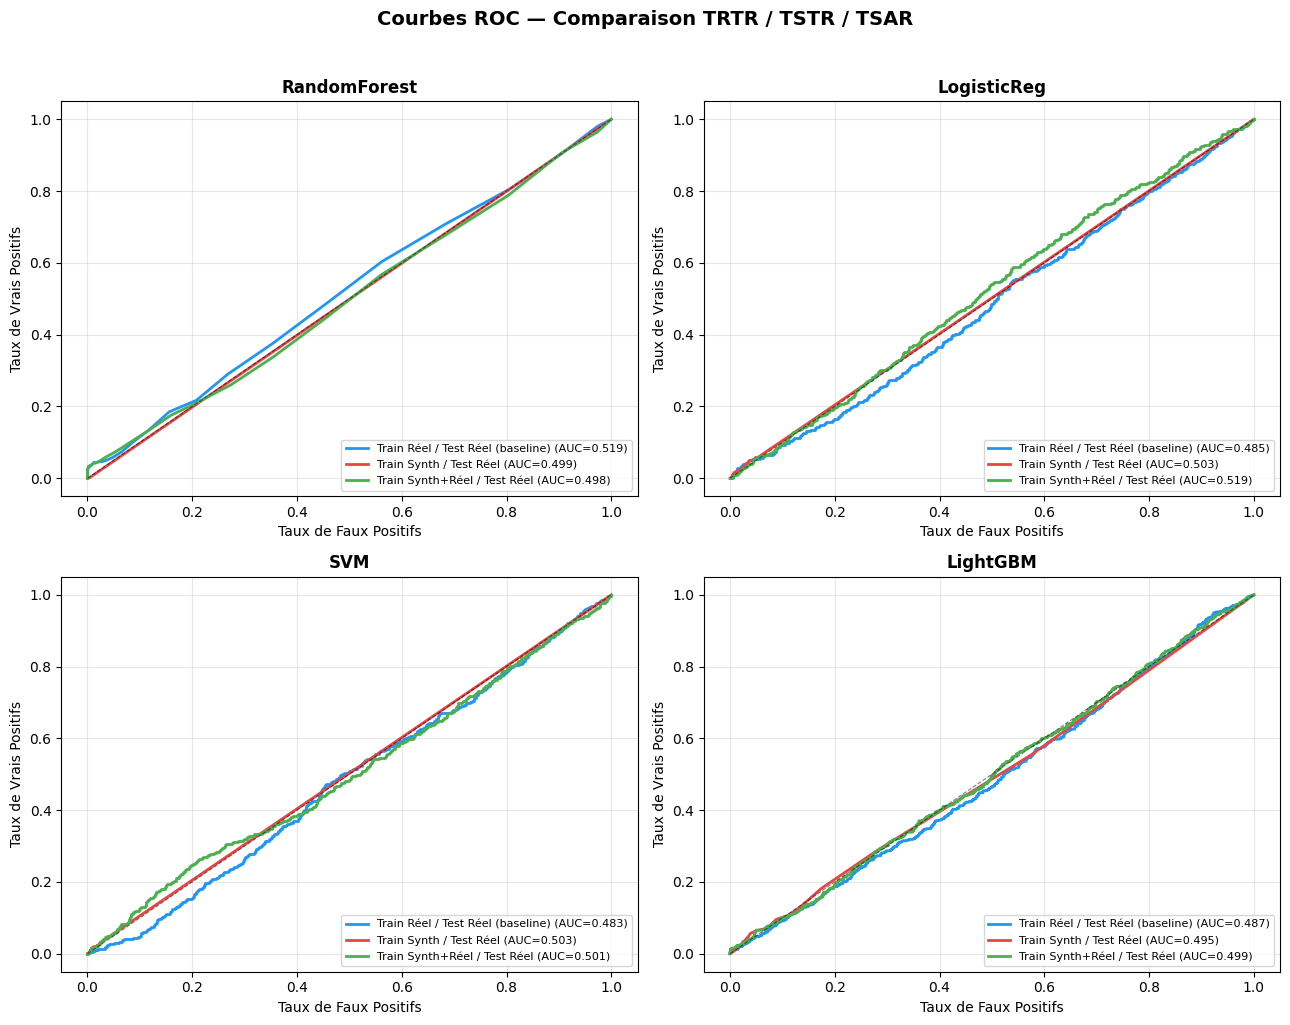

💾 Sauvegardé : roc_curves_comparison.png


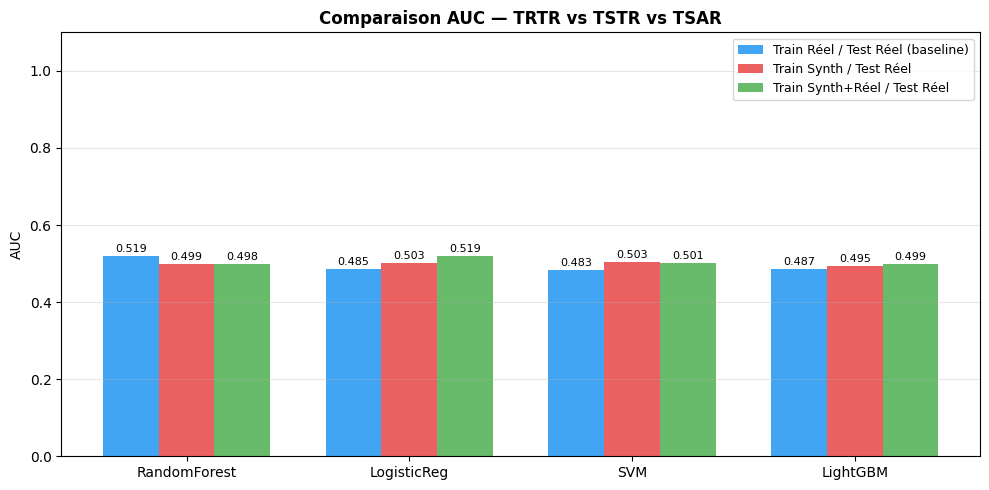

💾 Sauvegardé : comparison_auc.png


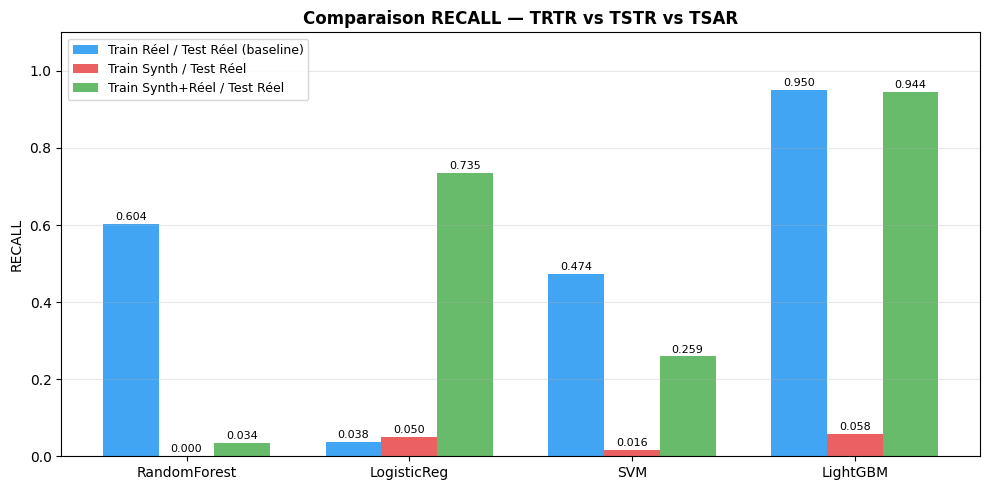

💾 Sauvegardé : comparison_recall.png

💾 Résultats sauvegardés dans resultats_tstr.json


In [7]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_curve, auc, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════
# 1. CHARGEMENT DES DONNÉES
# ═══════════════════════════════════════════════════════════

def load_real_data(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    print(f"✅ Données réelles chargées : {df.shape}")
    print(df["Fraudulent"].value_counts().to_string())
    return df


def load_synthetic_data(json_path: str) -> pd.DataFrame:
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    df = pd.DataFrame(data["transactions"])
    print(f"\n✅ Données synthétiques chargées : {df.shape}")
    print(df["Fraudulent"].value_counts().to_string())
    return df


# ═══════════════════════════════════════════════════════════
# 2. PREPROCESSING (réutilise la logique du notebook)
# ═══════════════════════════════════════════════════════════

def preprocess(df: pd.DataFrame, fit_encoders: dict = None) -> tuple:
    """
    Encode les variables catégorielles et sépare X / y.
    Si fit_encoders est fourni, applique les encodeurs existants
    (cas où on encode les synth. avec les encodeurs du réel).
    Retourne (X, y, encoders).
    """
    df = df.copy()

    # Suppression des colonnes non prédictives
    drop_cols = [c for c in ["User_ID", "Transaction_ID"] if c in df.columns]
    df.drop(columns=drop_cols, inplace=True, errors="ignore")

    # Valeurs manquantes : remplacées par la moyenne / mode
    for col in df.select_dtypes(include=["float64", "int64"]).columns:
        if col != "Fraudulent":
            df[col].fillna(df[col].mean(), inplace=True)
    for col in df.select_dtypes(include=["object", "category"]).columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

    y = df["Fraudulent"].astype(int)
    X = df.drop(columns=["Fraudulent"])

    encoders = fit_encoders if fit_encoders else {}
    for col in X.select_dtypes(include=["object", "category"]).columns:
        if col in encoders:
            # Gestion des catégories inconnues dans les synth.
            le = encoders[col]
            X[col] = X[col].apply(
                lambda v: le.transform([v])[0] if v in le.classes_ else -1
            )
        else:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            encoders[col] = le

    # Alignement des colonnes (synth. peut avoir des colonnes différentes)
    return X, y, encoders


def align_columns(X_source: pd.DataFrame, X_target: pd.DataFrame) -> pd.DataFrame:
    """Aligne les colonnes de X_source sur X_target (remplissage à 0 si manquant)."""
    for col in X_target.columns:
        if col not in X_source.columns:
            X_source[col] = 0
    return X_source[X_target.columns]


# ═══════════════════════════════════════════════════════════
# 3. MODÈLES (repris du notebook)
# ═══════════════════════════════════════════════════════════

MODELS = {
    "RandomForest":   RandomForestClassifier(n_estimators=100, random_state=42),
    "LogisticReg":    LogisticRegression(max_iter=1000, random_state=42),
    "SVM":            SVC(kernel="rbf", C=5, gamma="scale",
                          probability=True, random_state=42),
    "LightGBM":       lgb.LGBMClassifier(learning_rate=0.09, max_depth=-5,
                                          random_state=42, verbose=-1),
}


def evaluate_model(model, X_train, y_train, X_test, y_test) -> dict:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba_raw = model.predict_proba(X_test)

    # ── Correction : une seule classe apprise ──────────────
    classes = list(model.classes_)
    if 1 not in classes:
        # Le modèle n'a vu que des 0 → probabilité fraude = 0 partout
        y_pred_proba = np.zeros(len(X_test))
    elif 0 not in classes:
        # Le modèle n'a vu que des 1 → probabilité fraude = 1 partout
        y_pred_proba = np.ones(len(X_test))
    else:
        y_pred_proba = y_pred_proba_raw[:, 1]
    # ────────────────────────────────────────────────────────

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    auc_score = auc(fpr, tpr)

    youden   = tpr - fpr
    best_idx = np.argmax(youden)
    best_thresh = thresholds[best_idx]
    y_pred_opt  = (y_pred_proba >= best_thresh).astype(int)

    tn = np.sum((y_pred_opt == 0) & (np.array(y_test) == 0))
    fp = np.sum((y_pred_opt == 1) & (np.array(y_test) == 0))
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        "auc":         round(auc_score, 4),
        "accuracy":    round(accuracy_score(y_test, y_pred), 4),
        "recall":      round(recall_score(y_test, y_pred_opt, zero_division=0), 4),
        "specificity": round(specificity, 4),
        "precision":   round(precision_score(y_test, y_pred_opt, zero_division=0), 4),
        "f1":          round(f1_score(y_test, y_pred_opt, zero_division=0), 4),
        "youden":      round(float(youden[best_idx]), 4),
        "threshold":   round(float(best_thresh), 4),
        "fpr": fpr, "tpr": tpr,
    }


# ═══════════════════════════════════════════════════════════
# 4. TROIS PROTOCOLES D'ENTRAÎNEMENT
# ═══════════════════════════════════════════════════════════
#
#  A) TRTR — Train Real  / Test Real  (baseline du notebook)
#  B) TSTR — Train Synth / Test Real  (qualité des synth.)
#  C) TSAR — Train Synth+Real / Test Real (apport des synth.)
#
# ═══════════════════════════════════════════════════════════

def run_experiments(df_real, df_synth, test_size=0.2):
    X_real, y_real, encoders = preprocess(df_real)
    X_synth, y_synth, _      = preprocess(df_synth, fit_encoders=encoders)
    X_synth = align_columns(X_synth, X_real)

    X_train_r, X_test, y_train_r, y_test = train_test_split(
        X_real, y_real, test_size=test_size, random_state=42, stratify=y_real
    )

    # ── Correction TSTR : enrichir le synth. avec des légitimes réelles ──
    # Sans transactions légitimes, TSTR est trivial (modèle prédit toujours 1)
    # On prend autant de légitimes réelles que de fraudes synthétiques
    real_legit = X_train_r[y_train_r == 0]
    y_real_legit = y_train_r[y_train_r == 0]
    n_legit_to_add = min(len(real_legit), len(X_synth))

    real_legit_sample   = real_legit.sample(n=n_legit_to_add, random_state=42)
    y_legit_sample      = y_real_legit.loc[real_legit_sample.index]

    X_synth_balanced = pd.concat([X_synth, real_legit_sample], ignore_index=True)
    y_synth_balanced = pd.concat(
        [y_synth.reset_index(drop=True),
         y_legit_sample.reset_index(drop=True)],
        ignore_index=True
    )
    print(f"  TSTR — train : {y_synth_balanced.value_counts().to_dict()}")
    # ─────────────────────────────────────────────────────────────────────

    # ── TSAR : données réelles + fraudes synthétiques (augmentation classe minoritaire)
    # Les synth. sont tous Fraudulent=1 → enrichit uniquement la classe fraude
    X_train_aug = pd.concat([X_train_r, X_synth], ignore_index=True)
    y_train_aug = pd.concat(
        [y_train_r.reset_index(drop=True),
         y_synth.reset_index(drop=True)],
        ignore_index=True
    )
    print(f"  TSAR — train : {y_train_aug.value_counts().to_dict()}")

    results = {}
    for model_name, model_proto in MODELS.items():
        print(f"\n  📊 {model_name}...", flush=True)
        from sklearn.base import clone
        results[model_name] = {
            "TRTR": evaluate_model(clone(model_proto), X_train_r, y_train_r, X_test, y_test),
            "TSTR": evaluate_model(clone(model_proto), X_synth_balanced, y_synth_balanced, X_test, y_test),
            "TSAR": evaluate_model(clone(model_proto), X_train_aug, y_train_aug, X_test, y_test),
        }

    return results, X_test, y_test


# ═══════════════════════════════════════════════════════════
# 5. VISUALISATION (style notebook)
# ═══════════════════════════════════════════════════════════

PROTOCOL_COLORS = {
    "TRTR": "#2196F3",   # bleu  — baseline réel
    "TSTR": "#E84545",   # rouge — synthétique pur
    "TSAR": "#4CAF50",   # vert  — augmenté
}
PROTOCOL_LABELS = {
    "TRTR": "Train Réel / Test Réel (baseline)",
    "TSTR": "Train Synth / Test Réel",
    "TSAR": "Train Synth+Réel / Test Réel",
}

def plot_roc_curves(results: dict):
    """Courbes ROC comparatives — une sous-figure par modèle."""
    n = len(results)
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    axes = axes.flatten()

    for ax, (model_name, protocols) in zip(axes, results.items()):
        for proto, metrics in protocols.items():
            ax.plot(
                metrics["fpr"], metrics["tpr"],
                color=PROTOCOL_COLORS[proto],
                label=f"{PROTOCOL_LABELS[proto]} (AUC={metrics['auc']:.3f})",
                linewidth=2
            )
        ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.5)
        ax.set_title(model_name, fontsize=12, fontweight="bold")
        ax.set_xlabel("Taux de Faux Positifs")
        ax.set_ylabel("Taux de Vrais Positifs")
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(alpha=0.3)

    plt.suptitle("Courbes ROC — Comparaison TRTR / TSTR / TSAR",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("roc_curves_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Sauvegardé : roc_curves_comparison.png")


def build_summary_table(results: dict) -> pd.DataFrame:
    """
    Tableau récapitulatif au même format multi-index que le notebook.
    """
    metrics_to_show = ["auc", "recall", "specificity", "precision", "f1", "youden"]

    index   = pd.Index(results.keys(), name="Modèle")
    columns = pd.MultiIndex.from_tuples(
        [(proto, m)
         for proto in ["TRTR", "TSTR", "TSAR"]
         for m in metrics_to_show],
        names=["Protocole", "Métrique"]
    )

    rows = []
    for model_name, protocols in results.items():
        row = []
        for proto in ["TRTR", "TSTR", "TSAR"]:
            for m in metrics_to_show:
                row.append(protocols[proto].get(m, float("nan")))
        rows.append(row)

    return pd.DataFrame(rows, index=index, columns=columns)


def plot_metric_bars(summary: pd.DataFrame, metric: str = "auc"):
    """Barres comparatives pour une métrique donnée."""
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(summary.index))
    width = 0.25

    for i, proto in enumerate(["TRTR", "TSTR", "TSAR"]):
        vals = summary[proto][metric].values
        bars = ax.bar(x + i * width, vals, width,
                      label=PROTOCOL_LABELS[proto],
                      color=PROTOCOL_COLORS[proto], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x + width)
    ax.set_xticklabels(summary.index, fontsize=10)
    ax.set_ylabel(metric.upper())
    ax.set_title(f"Comparaison {metric.upper()} — TRTR vs TSTR vs TSAR",
                 fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"comparison_{metric}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"💾 Sauvegardé : comparison_{metric}.png")


def tstr_score(results: dict) -> float:
    """
    Score de qualité des données synthétiques :
    ratio moyen AUC_TSTR / AUC_TRTR sur tous les modèles.
    Un score proche de 1.0 indique que les synth. sont aussi
    informatifs que les données réelles.
    """
    ratios = [
        v["TSTR"]["auc"] / v["TRTR"]["auc"]
        for v in results.values()
        if v["TRTR"]["auc"] > 0
    ]
    return round(np.mean(ratios), 4)


# ═══════════════════════════════════════════════════════════
# 6. MAIN
# ═══════════════════════════════════════════════════════════

if __name__ == "__main__":

    # ── Chargement ──────────────────────────────────────────
    df_real  = load_real_data("../Fraud Detection Dataset.csv")
    # Utiliser les données synthétiques bayésiennes (équilibrées)
    df_synth = load_synthetic_data("transactions_synthetiques_bayes.json")

    # ── Expériences ─────────────────────────────────────────
    print("\n🚀 Lancement des expériences (TRTR / TSTR / TSAR)...")
    results, X_test, y_test = run_experiments(df_real, df_synth)

    # ── Tableau récapitulatif ────────────────────────────────
    summary = build_summary_table(results)
    print("\n=== Tableau récapitulatif ===")
    print(summary.to_string())

    # ── Score TSTR global ────────────────────────────────────
    score = tstr_score(results)
    print(f"\n📈 Score TSTR global (AUC_TSTR / AUC_TRTR) : {score:.4f}")
    if score >= 0.90:
        print("   ✅ Excellent — les données synthétiques sont très proches du réel")
    elif score >= 0.75:
        print("   ✅ Bon — les données capturent bien la structure")
    elif score >= 0.60:
        print("   ⚠️  Acceptable — à améliorer (plus d'échantillons, meilleur prompt)")
    else:
        print("   ❌ Insuffisant — les synth. n'apportent pas d'information utile")

    # ── Visualisations ───────────────────────────────────────
    plot_roc_curves(results)
    plot_metric_bars(summary, metric="auc")
    plot_metric_bars(summary, metric="recall")

    # ── Sauvegarde JSON ──────────────────────────────────────
    exportable = {
        model: {
            proto: {k: v for k, v in m.items() if k not in ("fpr", "tpr")}
            for proto, m in protocols.items()
        }
        for model, protocols in results.items()
    }
    exportable["tstr_score"] = score
    with open("resultats_tstr.json", "w", encoding="utf-8") as f:
        json.dump(exportable, f, indent=2, ensure_ascii=False)
    print("\n💾 Résultats sauvegardés dans resultats_tstr.json")